# Import Libraries 

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Connecting to data
file_path = (r"E:\Internship Report Square Pharmaceiticals PLC\Excel Workbook\Python Project\Sales and Marketing Call Center.csv")
df = pd.read_csv(file_path)
df

,Call_ID,Date,Agent_First_Name,Agent_Last_Name,Agent_Rating,Product_Discussed,Call_Duration_Minutes,Call_Outcome,Customer_Age,Callers_Name,Customer_Gender,State,Customer_Income_Bracket,Time_of_Day,Follow_Up_Call_Required,Repeat_Customer,Reason_Call_Abandoned
0,el-Pa,45359,Michael,Page,5.0,Loans,10.00,Success,25,Noah Smith,Male,New York,High,Afternoon,Yes,No,NaN
1,ah-Ha,45484,Elijah,Hawkins,4.9,Internet Package,26.22,Failure,20,Brian Anderson,Male,California,High,Morning,No,Yes,Technical Issues
2,ia-Ly,45396,Olivia,Lyons,5.0,Loans,10.00,Success,40,Loretta Williams,Female,Alabama,Low,Morning,No,No,NaN
3,ew-Cl,45635,Drew,Clay,4.4,Loans,2.00,Failure,20,Casey Reyes,Male,New York,High,Morning,No,No,Technical Issues
4,va-Sa,45613,Ava,Sandoval,5.0,Loans,2.00,Failure,35,Craig Mosley,Male,North Carolina,Low,Afternoon,Yes,Yes,Technical Issues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,el-Pa,45481,Michael,Page,4.1,Loans,10.00,Success,45,Michael Pittman,Male,Florida,Low,Afternoon,No,No,NaN
199996,na-Wi,45344,Katrina,Williams,4.7,Travel Package,33.69,Success,25,Jillian Howell,Female,North Carolina,Middle,Morning,No,No,NaN
199997,ue-La,45410,Monique,Lawrence,4.9,Internet Package,36.51,Success,40,Cody Howe,Male,Pennsylvania,Middle,Afternoon,Yes,No,NaN
199998,ia-Ly,45511,Olivia,Lyons,3.5,Loans,10.00,Success,15,Michelle Landry MD,Female,New York,Middle,Morning,Yes,No,NaN


# 1. Who are the top-performing agents based on Agent Rating?

In [15]:
# Combining the agents first and last name
df['Agent_Full_Name'] = df['Agent_First_Name'] + ' ' + df['Agent_Last_Name']

# Converting the agent rating to numeric value
df['Agent_Rating'] = pd.to_numeric(df['Agent_Rating'], errors = 'coerce')

# Agent the highest rating (5). filter and display only agents with 5 rating callers
highest_ratings = df[df['Agent_Rating'] == 5.0] [['Agent_Full_Name', 'Agent_Rating']].drop_duplicates()
highest_ratings

,Agent_Full_Name,Agent_Rating
0,Michael Page,5.0
2,Olivia Lyons,5.0
4,Ava Sandoval,5.0
6,Monique Lawrence,5.0
10,Elijah Hawkins,5.0
15,Liam Martinez,5.0
17,Samuel Smith,5.0
39,Drew Clay,5.0
48,Zoe Newman,5.0
53,Ray Mason,5.0


# 2. What is the average call duration by each agent?

In [21]:
# Converting the agent call duration to numeric value
df['Call_Duration_Minutes'] = pd.to_numeric(df['Call_Duration_Minutes'], errors = 'coerce')

# Calculate the average call duration
avg_call_duration = df.groupby('Agent_Full_Name')['Call_Duration_Minutes'].mean().round(2).reset_index()

# Sort call duration
sort_call_duration = avg_call_duration.sort_values(by="Call_Duration_Minutes",ascending = False)
print('All Agents Average Call Duration in Minutes')
sort_call_duration

All Agents Average Call Duration in Minutes


,Agent_Full_Name,Call_Duration_Minutes
5,Michael Page,19.70
3,Katrina Williams,19.56
0,Ava Sandoval,18.64
11,Sophia Delacruz,18.62
9,Samuel Smith,16.89
7,Olivia Lyons,16.62
4,Liam Martinez,16.61
6,Monique Lawrence,16.43
10,Sarah Walter,15.91
1,Drew Clay,15.66


# 3. Which agents have the highest success rates in closing calls?

In [27]:
# Filter only successful calls by agents
successful_calls = df[df['Call_Outcome'] == 'Success']

# Calculate the success Rate per Agent
successful_rate = (successful_calls.groupby('Agent_Full_Name').size() / df.groupby('Agent_Full_Name').size() )

# Convert decimal number to percentage strings
success_rate_percentage = successful_rate.apply(lambda x: f"{x:2%}")

# Reset Index and rename column
success_rate_percentage = success_rate_percentage.reset_index(name = '% of success')

# Sort the percentae
success_rate_percentage = success_rate_percentage.sort_values(by = '% of success', ascending=False)
success_rate_percentage

,Agent_Full_Name,% of success
9,Samuel Smith,90.550000%
6,Monique Lawrence,90.268750%
7,Olivia Lyons,90.050000%
4,Liam Martinez,89.930000%
5,Michael Page,89.900000%
3,Katrina Williams,89.775000%
1,Drew Clay,20.217857%
2,Elijah Hawkins,20.206250%
8,Ray Mason,20.060000%
0,Ava Sandoval,19.995000%


# 4. Are agent ratings correlated with call outcomes (e.g., higher ratings lead to more successful calls)?

<function matplotlib.pyplot.show(close=None, block=None)>

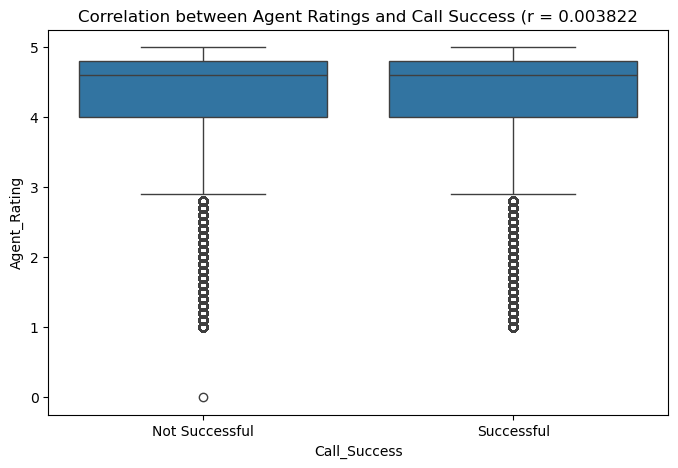

In [35]:
# Create a Binary Variable for call outcome from 1 to 0
df['Call_Success'] = np.where(df['Call_Outcome']=='Success',1,0)

# Calculate the correlation between Agent rating and call success
correlation =df[['Agent_Rating', 'Call_Success']].corr().iloc[0,1]

# Create Box Plot Chart
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Call_Success'],y=df['Agent_Rating'])

# Customize Axis Label and Title
plt.xticks(ticks=[0,1],labels = ["Not Successful", "Successful"])
plt.title(f"Correlation between Agent Ratings and Call Success (r = {correlation:2f}")
plt.show